# 📦 Transformación de Datos — Master Table RFM

Este notebook construye la **Master Table RFM** (Recency, Frequency, Monetary) a partir de las tablas crudas del dataset de Olist.

## ⚠️ Punto crítico: `customer_id` vs `customer_unique_id`
En este dataset, el campo `customer_id` en la tabla de órdenes **cambia con cada compra** (funciona como un ID de sesión).  
Para rastrear correctamente a un cliente a lo largo del tiempo, es **obligatorio** hacer el join con la tabla de clientes para obtener el `customer_unique_id`. Sin este paso, la **Frecuencia** de compra siempre será 1 y el modelo CLV no tendrá valor.

## Flujo del notebook
1. Carga de tablas crudas
2. Join de las tres tablas
3. Filtrado de órdenes entregadas (`order_status = 'delivered'`)
4. Conversión de timestamps
5. Inspección del resultado (tabla base para RFM)

---
## 1. Importación de librerías

In [2]:
# ── Manipulación y análisis de datos ─────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Modelado CLV: BG/NBD + Gamma-Gamma ───────────────────────────────────────
# lifetimes implementa los modelos probabilísticos estándar para predicción de CLV
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

# ── Calendario de feriados (detección de data drift estacional) ───────────────
# Usado para identificar Black Friday, fiestas nacionales (Brasil), etc.
# Permite corregir o ponderar picos artificiales en Recency / Frequency / Monetary
import holidays

# ── Configuración general de visualización ────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


---
## 2. Carga de tablas crudas

In [3]:
# ── Rutas de los archivos crudos ──────────────────────────────────────────────
PATH_ORDERS    = '../data/raw/olist_orders_dataset.csv'
PATH_ITEMS     = '../data/raw/olist_order_items_dataset.csv'
PATH_CUSTOMERS = '../data/raw/olist_customers_dataset.csv'

# ── Carga ─────────────────────────────────────────────────────────────────────
df_orders    = pd.read_csv(PATH_ORDERS)
df_items     = pd.read_csv(PATH_ITEMS)
df_customers = pd.read_csv(PATH_CUSTOMERS)

print(f'df_orders    → {df_orders.shape[0]:,} filas | {df_orders.shape[1]} columnas')
print(f'df_items     → {df_items.shape[0]:,} filas | {df_items.shape[1]} columnas')
print(f'df_customers → {df_customers.shape[0]:,} filas | {df_customers.shape[1]} columnas')

df_orders    → 99,441 filas | 8 columnas
df_items     → 112,650 filas | 7 columnas
df_customers → 99,441 filas | 5 columnas


In [4]:
# Vista rápida de cada tabla
print('=== df_orders ===')
display(df_orders.head(3))

print('\n=== df_items ===')
display(df_items.head(3))

print('\n=== df_customers ===')
display(df_customers.head(3))

=== df_orders ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



=== df_items ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



=== df_customers ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


---
## 3. Filtrado: solo órdenes entregadas (`order_status = 'delivered'`)

In [5]:
# Distribución de estados antes del filtro
print('Distribución de order_status (antes del filtro):')
print(df_orders['order_status'].value_counts())
print(f'\nTotal órdenes: {len(df_orders):,}')

Distribución de order_status (antes del filtro):
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Total órdenes: 99,441


In [6]:
# ── Filtro: solo 'delivered' ──────────────────────────────────────────────────
df_orders_delivered = df_orders[df_orders['order_status'] == 'delivered'].copy()

ordenes_descartadas = len(df_orders) - len(df_orders_delivered)
print(f'Órdenes entregadas : {len(df_orders_delivered):,}')
print(f'Órdenes descartadas: {ordenes_descartadas:,} ({ordenes_descartadas/len(df_orders)*100:.1f}%)')

Órdenes entregadas : 96,478
Órdenes descartadas: 2,963 (3.0%)


---
## 4. Conversión de timestamps a `datetime`

In [7]:
# Columnas de fecha disponibles en df_orders
cols_fecha = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in cols_fecha:
    df_orders_delivered[col] = pd.to_datetime(df_orders_delivered[col])

print('Tipos de dato después de la conversión:')
print(df_orders_delivered[cols_fecha].dtypes)

Tipos de dato después de la conversión:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


---
## 5. Joins: construcción de la tabla base

### Lógica de joins

```
df_orders_delivered
    └─ JOIN df_customers  ON customer_id          → agrega customer_unique_id ✅
    └─ JOIN df_items       ON order_id             → agrega price, freight_value
```

> **Nota:** `df_items` tiene múltiples ítems por orden. Agregaremos `price` y `freight_value` sumando por `order_id` antes del join para no inflar filas.

In [8]:
# ── 5.1 Agregar ítems por orden ───────────────────────────────────────────────
# Sumamos price y freight_value para obtener el valor total de cada orden
df_items_agg = (
    df_items
    .groupby('order_id', as_index=False)
    .agg(
        total_price         = ('price',         'sum'),
        total_freight       = ('freight_value', 'sum'),
        num_items           = ('order_item_id', 'count')
    )
)

# Valor total de la orden = precio de productos + flete
df_items_agg['order_value'] = df_items_agg['total_price'] + df_items_agg['total_freight']

print(f'df_items_agg → {df_items_agg.shape[0]:,} filas (una por order_id)')
display(df_items_agg.head(3))

df_items_agg → 98,666 filas (una por order_id)


,order_id,total_price,total_freight,num_items,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.9,13.29,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.9,19.93,1,259.83
2,000229ec398224ef6ca0657da4fc703e,199.0,17.87,1,216.87


In [9]:
# ── 5.2 Seleccionar columnas útiles de df_customers ───────────────────────────
# Solo necesitamos customer_id (clave de join) y customer_unique_id
df_customers_slim = df_customers[['customer_id', 'customer_unique_id']].copy()

# ── 5.3 Join 1: órdenes + customers → agrega customer_unique_id ───────────────
df_base = df_orders_delivered.merge(
    df_customers_slim,
    on='customer_id',
    how='left'
)

print(f'Después de join con customers: {df_base.shape}')
print(f'customer_unique_id nulos: {df_base["customer_unique_id"].isna().sum()}')

Después de join con customers: (96478, 9)
customer_unique_id nulos: 0


In [10]:
# ── 5.4 Join 2: base + items_agg → agrega order_value ────────────────────────
df_base = df_base.merge(
    df_items_agg[['order_id', 'order_value', 'total_price', 'total_freight', 'num_items']],
    on='order_id',
    how='left'
)

print(f'Después de join con items: {df_base.shape}')
print(f'order_value nulos: {df_base["order_value"].isna().sum()}')

display(df_base.head(3))

Después de join con items: (96478, 13)
order_value nulos: 0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,order_value,total_price,total_freight,num_items
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,38.71,29.99,8.72,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,141.46,118.70,22.76,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,179.12,159.90,19.22,1


---
## 6. Inspección y validación de la tabla base

In [11]:
# ── Resumen general ────────────────────────────────────────────────────────────
print('=== RESUMEN DE LA TABLA BASE ===')
print(f'Filas       : {df_base.shape[0]:,}')
print(f'Columnas    : {df_base.shape[1]}')
print(f'Clientes únicos (customer_unique_id): {df_base["customer_unique_id"].nunique():,}')
print(f'Órdenes únicas (order_id)           : {df_base["order_id"].nunique():,}')
print(f'Período     : {df_base["order_purchase_timestamp"].min().date()} → {df_base["order_purchase_timestamp"].max().date()}')
print(f'Valor medio por orden (BRL): R$ {df_base["order_value"].mean():.2f}')

=== RESUMEN DE LA TABLA BASE ===
Filas       : 96,478
Columnas    : 13
Clientes únicos (customer_unique_id): 93,358
Órdenes únicas (order_id)           : 96,478
Período     : 2016-09-15 → 2018-08-29
Valor medio por orden (BRL): R$ 159.83


In [12]:
# ── Chequeo de nulos ───────────────────────────────────────────────────────────
nulos = df_base.isna().sum()
nulos_pct = (nulos / len(df_base) * 100).round(2)
resumen_nulos = pd.DataFrame({'nulos': nulos, 'pct': nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos['nulos'] > 0]

if resumen_nulos.empty:
    print('✅ No hay valores nulos en las columnas clave')
else:
    print('⚠️ Columnas con valores nulos:')
    display(resumen_nulos)

⚠️ Columnas con valores nulos:


,nulos,pct
order_approved_at,14,0.01
order_delivered_carrier_date,2,0.00
order_delivered_customer_date,8,0.01


In [13]:
# ── Validación clave: verificar que Frecuencia > 1 existe ─────────────────────
# Si el join con customers fue correcto, habrá clientes con más de 1 orden
frecuencia_por_cliente = (
    df_base
    .groupby('customer_unique_id')['order_id']
    .nunique()
    .rename('num_ordenes')
)

print('Distribución de número de órdenes por cliente:')
print(frecuencia_por_cliente.value_counts().head(10).to_string())
print(f'\nClientes con más de 1 orden: {(frecuencia_por_cliente > 1).sum():,}')
print(f'Máximo de órdenes por cliente: {frecuencia_por_cliente.max()}')
print()

if (frecuencia_por_cliente > 1).sum() == 0:
    print('❌ ERROR: Todos los clientes tienen Frecuencia = 1. Revisar el join con customers.')
else:
    print('✅ Join correcto: existen clientes con múltiples órdenes.')

Distribución de número de órdenes por cliente:
num_ordenes
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1

Clientes con más de 1 orden: 2,801
Máximo de órdenes por cliente: 15

✅ Join correcto: existen clientes con múltiples órdenes.


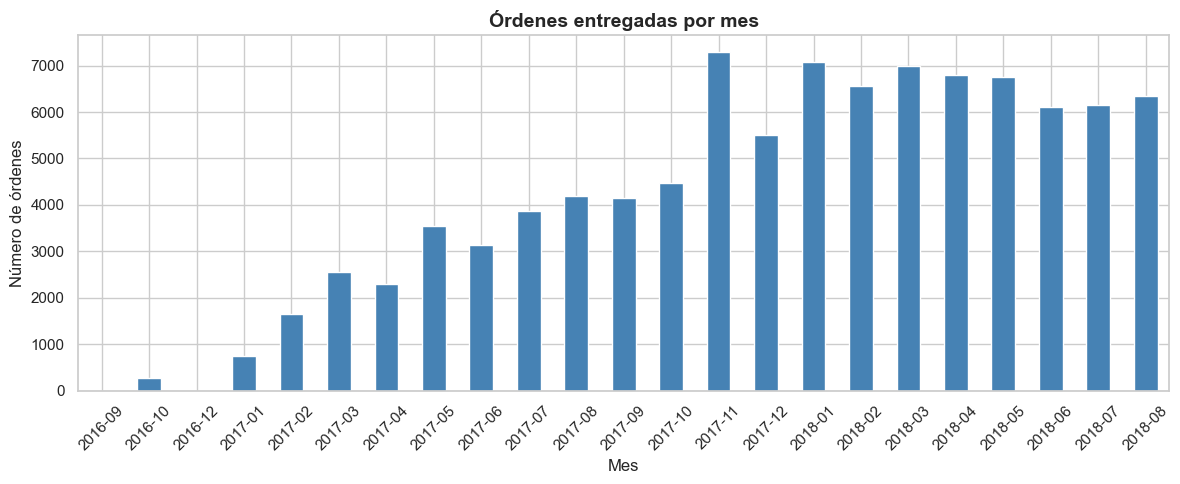

In [14]:
# ── Distribución temporal de órdenes ──────────────────────────────────────────
fig, ax = plt.subplots()
df_base['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('Órdenes entregadas por mes', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Número de órdenes')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 7. Columnas finales de la tabla base

La tabla `df_base` ya está lista para construir la Matriz RFM. Columnas clave:

| Columna | Uso RFM |
|---|---|
| `customer_unique_id` | Identificador real del cliente |
| `order_purchase_timestamp` | Cálculo de **Recency** |
| `order_id` | Conteo de compras → **Frequency** |
| `order_value` | Suma de gasto → **Monetary** |

In [15]:
# Columnas disponibles en df_base
print('Columnas de df_base:')
for col in df_base.columns:
    print(f'  • {col} ({df_base[col].dtype})')

Columnas de df_base:
  • order_id (object)
  • customer_id (object)
  • order_status (object)
  • order_purchase_timestamp (datetime64[ns])
  • order_approved_at (datetime64[ns])
  • order_delivered_carrier_date (datetime64[ns])
  • order_delivered_customer_date (datetime64[ns])
  • order_estimated_delivery_date (datetime64[ns])
  • customer_unique_id (object)
  • order_value (float64)
  • total_price (float64)
  • total_freight (float64)
  • num_items (int64)


In [16]:
# Vista final
display(df_base[[
    'customer_unique_id',
    'order_id',
    'order_purchase_timestamp',
    'order_value'
]].head(10))

,customer_unique_id,order_id,order_purchase_timestamp,order_value
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,38.71
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,141.46
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,179.12
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,72.20
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,28.62
5,80bb27c7c16e8f973207a5086ab329e2,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,175.26
6,932afa1e708222e5821dac9cd5db4cae,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,75.16
7,39382392765b6dc74812866ee5ee92a7,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09,35.95
8,299905e3934e9e181bfb2e164dd4b4f8,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07-29 11:55:02,169.76
9,f2a85dec752b8517b5e58a06ff3cd937,e6ce16cb79ec1d90b1da9085a6118aeb,2017-05-16 19:41:10,259.06



# 8. Construcción de la Matriz RFM

 Usamos `summary_data_from_transaction_data` de **lifetimes** para calcular
 automáticamente las tres métricas por cliente desde la tabla de transacciones:

 | Métrica | Definición en lifetimes |
 |---|---|
 | `frequency` | Número de compras *repetidas* (compras totales − 1) |
 | `recency` | Días entre la primera y la última compra |
 | `T` | Días entre la primera compra y el fin de observación |
 | `monetary_value` | Valor **medio** por compra repetida (excluye la primera) |

 > **Nota:** lifetimes usa esta convención porque el BG/NBD modela las compras
 > *después* de la primera, que es la que "activa" al cliente.
 

In [18]:
# Fecha de referencia = último día de observación en el dataset
fecha_fin = df_base['order_purchase_timestamp'].max()

# summary_data_from_transaction_data construye el resumen RFM directamente
# desde transacciones individuales. Usa freq='D' (días).
rfm = summary_data_from_transaction_data(
    transactions        = df_base,
    customer_id_col     = 'customer_unique_id',
    datetime_col        = 'order_purchase_timestamp',
    monetary_value_col  = 'order_value',
    observation_period_end = fecha_fin,
    freq                = 'D'
)

print(f'Clientes en la matriz RFM: {len(rfm):,}')
print(f'\nEstadísticas descriptivas:')
display(rfm.describe().round(2))

Clientes en la matriz RFM: 93,358

Estadísticas descriptivas:


,frequency,recency,T,monetary_value
count,93358.00,93358.00,93358.00,93358.00
mean,0.02,2.65,240.12,3.26
std,0.18,25.01,153.10,32.20
min,0.00,0.00,0.00,0.00
25%,0.00,0.00,116.00,0.00
50%,0.00,0.00,221.00,0.00
75%,0.00,0.00,350.00,0.00
max,14.00,633.00,713.00,2405.28


### Distribución de las métricas RFM
# =============================================================================

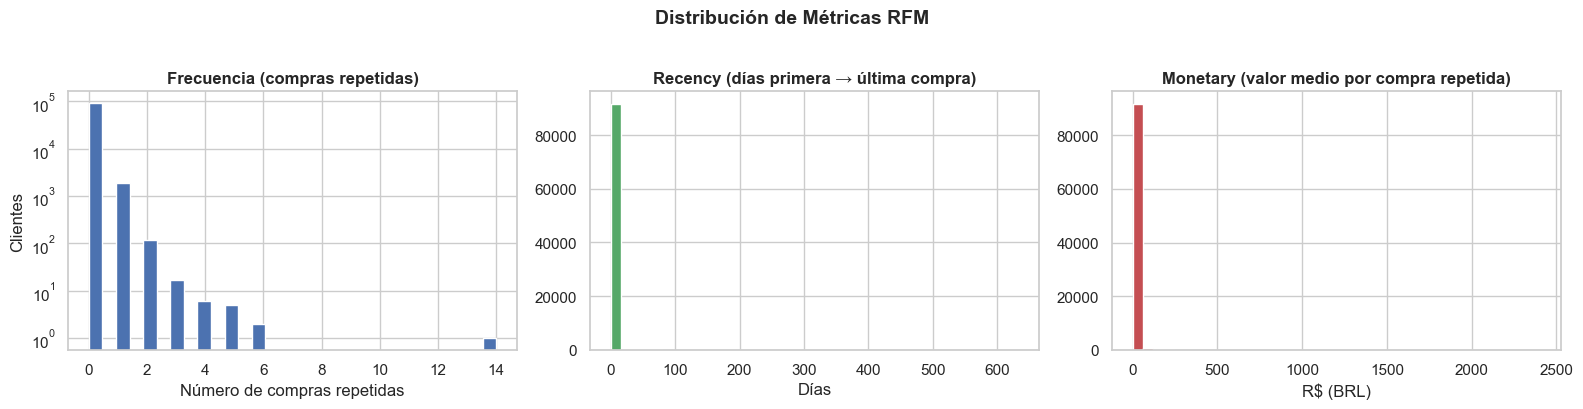


Clientes con frecuencia = 0 (una sola compra): 91,343 (97.8%)
Clientes con frecuencia > 0 (compradores recurrentes): 2,015 (2.2%)


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Frequency
axes[0].hist(rfm['frequency'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Frecuencia (compras repetidas)', fontweight='bold')
axes[0].set_xlabel('Número de compras repetidas')
axes[0].set_ylabel('Clientes')
axes[0].set_yscale('log')

# Recency
axes[1].hist(rfm['recency'], bins=40, color='#55A868', edgecolor='white')
axes[1].set_title('Recency (días primera → última compra)', fontweight='bold')
axes[1].set_xlabel('Días')

# Monetary
axes[2].hist(rfm['monetary_value'], bins=40, color='#C44E52', edgecolor='white')
axes[2].set_title('Monetary (valor medio por compra repetida)', fontweight='bold')
axes[2].set_xlabel('R$ (BRL)')

plt.suptitle('Distribución de Métricas RFM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nClientes con frecuencia = 0 (una sola compra): {(rfm['frequency'] == 0).sum():,} "
      f"({(rfm['frequency'] == 0).mean()*100:.1f}%)")
print(f"Clientes con frecuencia > 0 (compradores recurrentes): {(rfm['frequency'] > 0).sum():,} "
      f"({(rfm['frequency'] > 0).mean()*100:.1f}%)")

 ---
 ## 9. Modelo BG/NBD — Frecuencia de compra futura

 El modelo **Beta-Geo / Negative Binomial Distribution** estima:
 - La probabilidad de que un cliente **siga activo** ('vivo')
 - El número esperado de transacciones futuras dado su historial RFM

 ### Parámetros que aprende el modelo
 | Parámetro | Significado |
 |---|---|
 | `r`, `α` | Forma de la distribución de tasa de compra (NBD) |
 | `a`, `b` | Forma de la distribución de probabilidad de abandono (Beta) |
 =============================================================================


In [20]:
bgf = BetaGeoFitter(penalizer_coef=0.001)

bgf.fit(
    frequency = rfm['frequency'],
    recency   = rfm['recency'],
    T         = rfm['T']
)

print('✅ Modelo BG/NBD entrenado correctamente')
print(f'\nParámetros aprendidos:')
print(bgf.summary)

✅ Modelo BG/NBD entrenado correctamente

Parámetros aprendidos:
            coef  se(coef)  lower 95% bound  upper 95% bound
r       0.016708  0.000945         0.014856         0.018560
alpha  74.184410  7.351507        59.775457        88.593364
a       0.351124  0.049380         0.254340         0.447909
b       0.061596  0.010107         0.041787         0.081405



 ### Validación BG/NBD: frecuencia real vs predicha

 Si el modelo es bueno, la curva predicha (línea) debe coincidir con las
 barras del histograma de frecuencias reales.

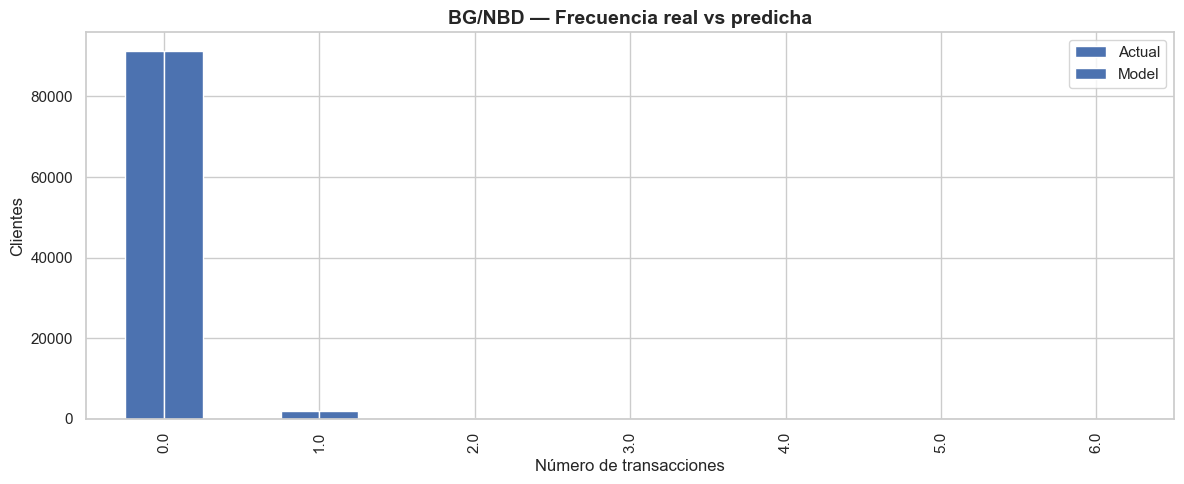

In [21]:
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix
from lifetimes.plotting import plot_period_transactions

fig, ax = plt.subplots(figsize=(12, 5))
plot_period_transactions(bgf, ax=ax, color='#4C72B0')
ax.set_title('BG/NBD — Frecuencia real vs predicha', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de transacciones')
ax.set_ylabel('Clientes')
plt.tight_layout()
plt.show()


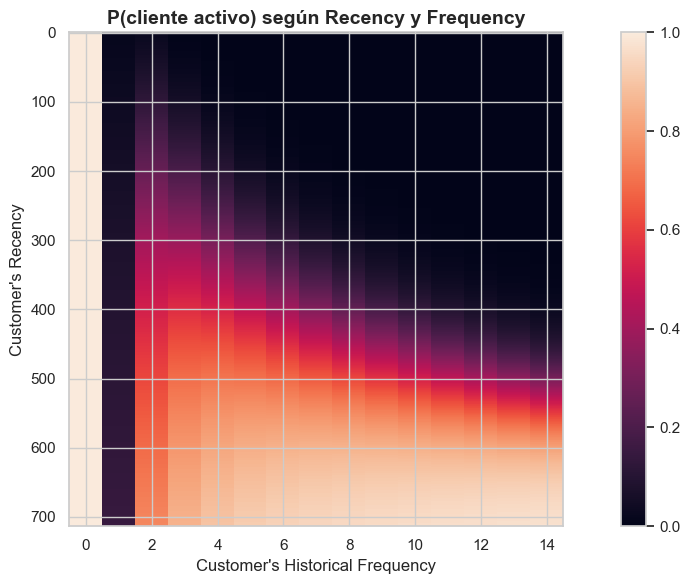

In [23]:
plt.figure(figsize=(12, 6))
plot_probability_alive_matrix(bgf)
plt.gca().set_title('P(cliente activo) según Recency y Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# Cuántas compras esperamos en los próximos 90 días para cada cliente
horizonte_dias = 90

rfm['compras_esperadas_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t         = horizonte_dias,
    frequency = rfm['frequency'],
    recency   = rfm['recency'],
    T         = rfm['T']
)

rfm['prob_activo'] = bgf.conditional_probability_alive(
    frequency = rfm['frequency'],
    recency   = rfm['recency'],
    T         = rfm['T']
)

print(f'Top 10 clientes por compras esperadas en {horizonte_dias} días:')
display(
    rfm[['frequency', 'recency', 'T', 'monetary_value', 'compras_esperadas_90d', 'prob_activo']]
    .sort_values('compras_esperadas_90d', ascending=False)
    .head(10)
    .round(3)
)

Top 10 clientes por compras esperadas en 90 días:


,frequency,recency,T,monetary_value,compras_esperadas_90d,prob_activo
customer_unique_id,,,,,,
8d50f5eadf50201ccdcedfb9e2ac8455,14.0,428.0,437.0,59.109,2.314,0.967
ca77025e7201e3b30c44b472ff346268,6.0,235.0,324.0,138.942,0.991,0.759
394ac4de8f3acb14253c177f0e15bc58,4.0,236.0,250.0,149.282,0.933,0.880
e0836a97eaae86ac4adc26fbb334a527,2.0,62.0,64.0,32.955,0.874,0.746
6469f99c1f9dfae7733b25662e7f1782,5.0,282.0,344.0,133.412,0.870,0.838
dc813062e0fc23409cd255f7f53c7074,5.0,418.0,424.0,139.404,0.803,0.916
bc3e7032668d3f411c227eec09221362,2.0,59.0,75.0,72.535,0.772,0.706
fe81bb32c243a86b2f86fbf053fe6140,4.0,242.0,311.0,381.745,0.717,0.798
6a9e15d6fa8ce1cabf193c21aa577f64,2.0,63.0,87.0,148.725,0.698,0.686


 ---
 ## 10. Modelo Gamma-Gamma — Valor monetario promedio

 El modelo **Gamma-Gamma** estima cuánto **gasta en promedio** un cliente
 por transacción, condicionado a que realice compras.

 > ⚠️ Solo se entrena con clientes que tienen `frequency > 0` (compradores
 > recurrentes), ya que el modelo necesita al menos 2 transacciones para
 > estimar la variabilidad del gasto.

 ### Supuesto clave
 La frecuencia de compra y el valor monetario son **independientes**.
 Validaremos esto con la correlación entre ambas variables.
 =============================================================================

In [25]:
compradores_recurrentes = rfm[rfm['frequency'] > 0].copy()

corr = compradores_recurrentes[['frequency', 'monetary_value']].corr().iloc[0, 1]
print(f'Correlación Frequency–Monetary (compradores recurrentes): {corr:.4f}')

if abs(corr) < 0.3:
    print('✅ Correlación baja → supuesto de independencia razonablemente cumplido.')
else:
    print('⚠️  Correlación moderada/alta → interpretar resultados con precaución.')

print(f'\nCompradores recurrentes para entrenar Gamma-Gamma: {len(compradores_recurrentes):,}')

Correlación Frequency–Monetary (compradores recurrentes): 0.0014
✅ Correlación baja → supuesto de independencia razonablemente cumplido.

Compradores recurrentes para entrenar Gamma-Gamma: 2,015


In [26]:
ggf = GammaGammaFitter(penalizer_coef=0.001)

ggf.fit(
    frequency     = compradores_recurrentes['frequency'],
    monetary_value= compradores_recurrentes['monetary_value']
)

print('✅ Modelo Gamma-Gamma entrenado correctamente')
print(f'\nParámetros aprendidos:')
print(ggf.summary)

✅ Modelo Gamma-Gamma entrenado correctamente

Parámetros aprendidos:
        coef  se(coef)  lower 95% bound  upper 95% bound
p  10.296773  0.298592         9.711533        10.882013
q   1.336367  0.039096         1.259739         1.412996
v   9.622032  0.304657         9.024903        10.219160


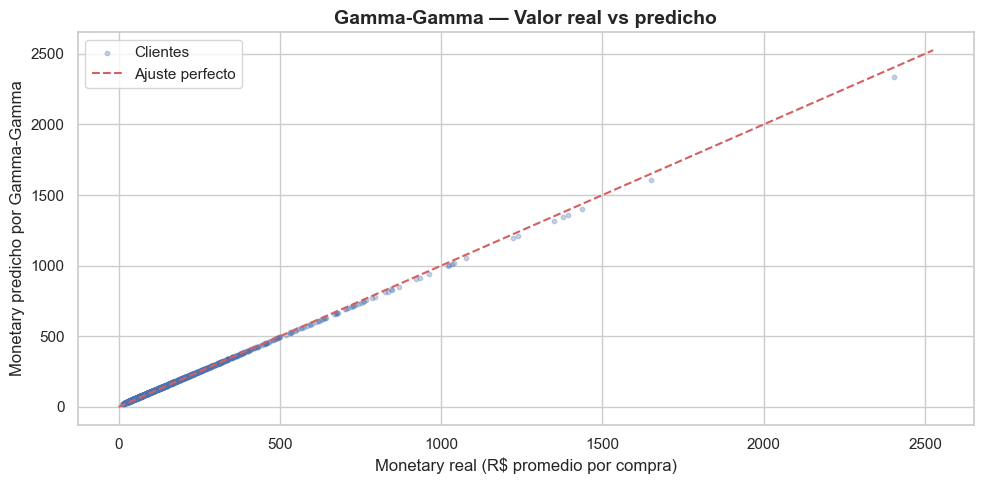

MAE Gamma-Gamma sobre compradores recurrentes: R$ 5.66


In [27]:
# Valor monetario predicho por el modelo para compradores recurrentes
compradores_recurrentes['monetary_predicho'] = ggf.conditional_expected_average_profit(
    frequency      = compradores_recurrentes['frequency'],
    monetary_value = compradores_recurrentes['monetary_value']
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    compradores_recurrentes['monetary_value'],
    compradores_recurrentes['monetary_predicho'],
    alpha=0.3, s=10, color='#4C72B0', label='Clientes'
)
# Línea de identidad perfecta
lim_max = compradores_recurrentes[['monetary_value', 'monetary_predicho']].max().max() * 1.05
ax.plot([0, lim_max], [0, lim_max], 'r--', linewidth=1.5, label='Ajuste perfecto')
ax.set_xlabel('Monetary real (R$ promedio por compra)')
ax.set_ylabel('Monetary predicho por Gamma-Gamma')
ax.set_title('Gamma-Gamma — Valor real vs predicho', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Error medio absoluto como métrica de ajuste
mae = np.abs(
    compradores_recurrentes['monetary_value'] - compradores_recurrentes['monetary_predicho']
).mean()
print(f'MAE Gamma-Gamma sobre compradores recurrentes: R$ {mae:.2f}')

 ---
 ## 11. CLV combinado: BG/NBD × Gamma-Gamma

 Combinamos ambos modelos para obtener el **Customer Lifetime Value** proyectado
 a 12 meses, descontado a tasa mensual.

 ```
 CLV = (compras esperadas) × (valor medio predicho) × (factor de descuento)
 ```
 =============================================================================


In [28]:
TASA_DESCUENTO_MENSUAL = 0.01   # 1 % mensual (ajustar según negocio)
HORIZONTE_MESES        = 12

clv = ggf.customer_lifetime_value(
    transaction_prediction_model = bgf,
    frequency                    = rfm['frequency'],
    recency                      = rfm['recency'],
    T                            = rfm['T'],
    monetary_value               = rfm['monetary_value'],
    time                         = HORIZONTE_MESES,       # meses
    freq                         = 'D',                   # unidad de recency/T
    discount_rate                = TASA_DESCUENTO_MENSUAL
)

rfm['clv_12m'] = clv

print(f'CLV a {HORIZONTE_MESES} meses — estadísticas:')
print(rfm['clv_12m'].describe().round(2))

CLV a 12 meses — estadísticas:
count    93358.00
mean         4.82
std          9.63
min          0.27
25%          3.00
50%          3.97
75%          5.46
max        991.86
Name: clv_12m, dtype: float64


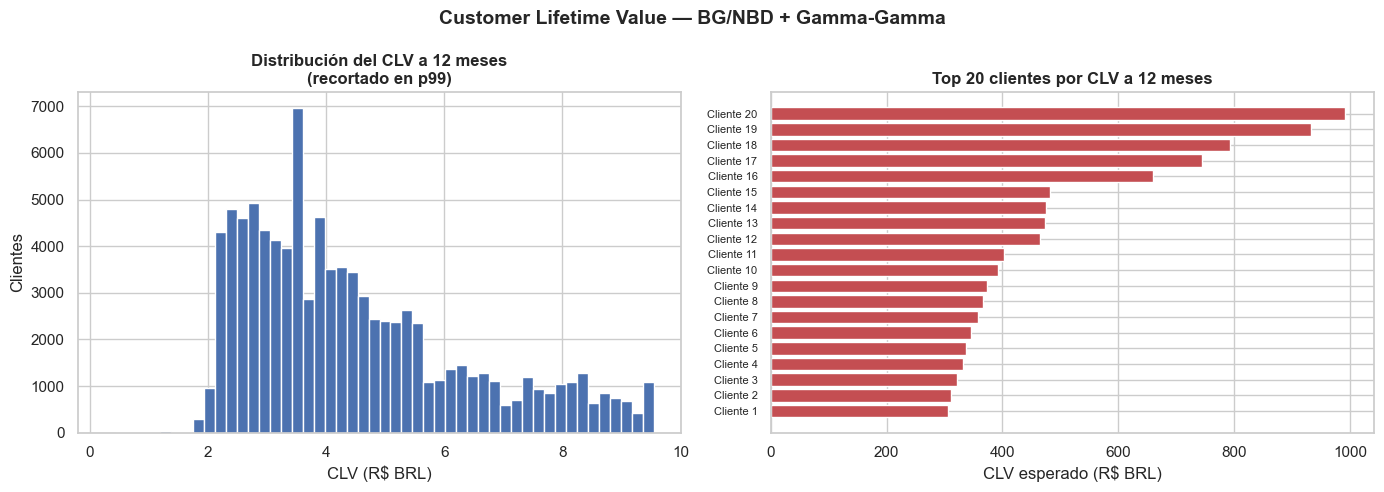

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma (escala log para manejar la cola larga)
axes[0].hist(rfm['clv_12m'].clip(upper=rfm['clv_12m'].quantile(0.99)),
             bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribución del CLV a 12 meses\n(recortado en p99)', fontweight='bold')
axes[0].set_xlabel('CLV (R$ BRL)')
axes[0].set_ylabel('Clientes')

# Top 20 clientes
top20 = rfm['clv_12m'].nlargest(20).sort_values()
axes[1].barh(range(len(top20)), top20.values, color='#C44E52')
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels([f'Cliente {i+1}' for i in range(len(top20))], fontsize=8)
axes[1].set_title('Top 20 clientes por CLV a 12 meses', fontweight='bold')
axes[1].set_xlabel('CLV esperado (R$ BRL)')

plt.suptitle('Customer Lifetime Value — BG/NBD + Gamma-Gamma', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
print('=== RESUMEN FINAL — MATRIZ RFM + CLV ===')
display(
    rfm[['frequency', 'recency', 'T', 'monetary_value',
         'compras_esperadas_90d', 'prob_activo', 'clv_12m']]
    .sort_values('clv_12m', ascending=False)
    .head(15)
    .round(2)
)

print(f'\nCLV total proyectado a {HORIZONTE_MESES} meses (suma): R$ {rfm["clv_12m"].sum():,.2f}')
print(f'CLV medio por cliente                              : R$ {rfm["clv_12m"].mean():,.2f}')
print(f'Clientes con CLV > R$ 500                         : {(rfm["clv_12m"] > 500).sum():,}')


=== RESUMEN FINAL — MATRIZ RFM + CLV ===


,frequency,recency,T,monetary_value,compras_esperadas_90d,prob_activo,clv_12m
customer_unique_id,,,,,,,
397b44d5bb99eabf54ea9c2b41ebb905,3.0,157.0,230.0,489.96,0.61,0.72,991.86
fe81bb32c243a86b2f86fbf053fe6140,4.0,242.0,311.0,381.74,0.72,0.80,932.55
4facc2e6fbc2bffab2fea92d2b4aa7e4,3.0,421.0,437.0,532.32,0.43,0.84,793.63
297ec5afd18366f5ba27520cc4954151,2.0,85.0,194.0,701.16,0.33,0.51,744.61
c8460e4251689ba205045f3ea17884a1,1.0,1.0,22.0,2405.28,0.10,0.12,659.50
8d50f5eadf50201ccdcedfb9e2ac8455,14.0,428.0,437.0,59.11,2.31,0.97,482.12
ca77025e7201e3b30c44b472ff346268,6.0,235.0,324.0,138.94,0.99,0.76,475.18
394ac4de8f3acb14253c177f0e15bc58,4.0,236.0,250.0,149.28,0.93,0.88,473.04
1da09dd64e235e7c2f29a4faff33535c,2.0,246.0,476.0,845.00,0.16,0.50,465.61



CLV total proyectado a 12 meses (suma): R$ 449,732.36
CLV medio por cliente                              : R$ 4.82
Clientes con CLV > R$ 500                         : 5


 ---
 ## 12. Persistencia de modelos y datos

 ### Estrategia de guardado para modelos `lifetimes`
 Los modelos de `lifetimes` no son serializables con `pickle` porque durante
 el `.fit()` guardan internamente **lambdas de `autograd`** que `pickle` no
 puede manejar (`AttributeError: Can't get local object 'BetaGeoFitter.fit.<locals>.<lambda>'`).

 La solución es guardar **solo los parámetros ajustados** (simples floats)
 en formato **JSON** (stdlib) y reconstruir el modelo al cargarlo.

 | Archivo | Contenido | Formato |
 |---|---|---|
 | `models/bgf_params.json` | Parámetros ajustados de BG/NBD (`r, α, a, b`) | JSON |
 | `models/ggf_params.json` | Parámetros ajustados de Gamma-Gamma (`p, q, v`) | JSON |
 | `data/processed/rfm_clv.parquet` | Matriz RFM + predicciones + CLV | Parquet |
 =============================================================================


In [32]:
import json
import os

# ── Rutas de destino ──────────────────────────────────────────────────────────
PATH_MODELS  = '../models'
PATH_PARQUET = '../data/processed/rfm_clv.parquet'

# Crear carpetas si no existen
os.makedirs(PATH_MODELS, exist_ok=True)
os.makedirs(os.path.dirname(PATH_PARQUET), exist_ok=True)

# ── Guardar parámetros del modelo BG/NBD ────────────────────────────────────
# bgf.params_ es un dict con los 4 parámetros: r, alpha, a, b
ruta_bgf = os.path.join(PATH_MODELS, 'bgf_params.json')
params_bgf = {
    'model':          'BetaGeoFitter',
    'penalizer_coef': 0.001,
    'params':         {k: float(v) for k, v in bgf.params_.items()}
}
with open(ruta_bgf, 'w', encoding='utf-8') as f:
    json.dump(params_bgf, f, indent=2, ensure_ascii=False)
print(f'✅ BG/NBD guardado      → {ruta_bgf}')
print(f'   Parámetros: {params_bgf["params"]}')

# ── Guardar parámetros del modelo Gamma-Gamma ────────────────────────────────
# ggf.params_ es un dict con los 3 parámetros: p, q, v
ruta_ggf = os.path.join(PATH_MODELS, 'ggf_params.json')
params_ggf = {
    'model':          'GammaGammaFitter',
    'penalizer_coef': 0.001,
    'params':         {k: float(v) for k, v in ggf.params_.items()}
}
with open(ruta_ggf, 'w', encoding='utf-8') as f:
    json.dump(params_ggf, f, indent=2, ensure_ascii=False)
print(f'✅ Gamma-Gamma guardado → {ruta_ggf}')
print(f'   Parámetros: {params_ggf["params"]}')

# ── Guardar matriz RFM + CLV como Parquet ────────────────────────────────────
rfm.to_parquet(PATH_PARQUET, index=True)
print(f'\n✅ RFM + CLV guardado   → {PATH_PARQUET}')
print(f'   Shape: {rfm.shape} | Columnas: {list(rfm.columns)}')

# ── Verificación de lectura round-trip ───────────────────────────────────────
rfm_check = pd.read_parquet(PATH_PARQUET)
assert rfm_check.shape == rfm.shape, '❌ Error: el parquet guardado no coincide con el original'
print(f'\n✅ Verificación OK — parquet leído correctamente ({rfm_check.shape[0]:,} filas)')

# ── Ejemplo de cómo recargar los modelos en otro notebook ────────────────────
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📂 Para recargar los modelos en otro notebook:

  import json
  from lifetimes import BetaGeoFitter, GammaGammaFitter

  with open('../models/bgf_params.json') as f:
      data = json.load(f)
  bgf = BetaGeoFitter(penalizer_coef=data['penalizer_coef'])
  bgf.params_ = data['params']

  with open('../models/ggf_params.json') as f:
      data = json.load(f)
  ggf = GammaGammaFitter(penalizer_coef=data['penalizer_coef'])
  ggf.params_ = data['params']
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

✅ BG/NBD guardado      → ../models\bgf_params.json
   Parámetros: {'r': 0.01670803690342116, 'alpha': 74.18441048220838, 'a': 0.3511244055576151, 'b': 0.06159585566303507}
✅ Gamma-Gamma guardado → ../models\ggf_params.json
   Parámetros: {'p': 10.296773069777519, 'q': 1.336367324316288, 'v': 9.622031565155279}

✅ RFM + CLV guardado   → ../data/processed/rfm_clv.parquet
   Shape: (93358, 7) | Columnas: ['frequency', 'recency', 'T', 'monetary_value', 'compras_esperadas_90d', 'prob_activo', 'clv_12m']

✅ Verificación OK — parquet leído correctamente (93,358 filas)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📂 Para recargar los modelos en otro notebook:

  import json
  from lifetimes import BetaGeoFitter, GammaGammaFitter

  with open('../models/bgf_params.json') as f:
      data = json.load(f)
  bgf = BetaGeoFitter(penalizer_coef=data['penalizer_coef'])
  bgf.params_ = data['params']

  with open('../models/ggf_params.json') as f:
      data = json.load(f)
  ggf = GammaGamm

 ---
 ## 📋 Registro de hiperparámetros y métricas del modelo

 ### Hiperparámetros usados

 | Modelo | Hiperparámetro | Valor | Descripción |
 |---|---|---|---|
 | BetaGeoFitter | `penalizer_coef` | `0.001` | Regularización L2 leve para evitar overfitting. Valor por defecto recomendado para datasets con pocos compradores recurrentes. |
 | GammaGammaFitter | `penalizer_coef` | `0.001` | Idem. Estabiliza la estimación cuando hay clientes con muy pocas repeticiones. |
 | Horizonte predicción | `horizonte_dias` | `90` | Ventana de compras esperadas en el corto plazo. |
 | Horizonte CLV | `HORIZONTE_MESES` | `12` | CLV proyectado a 1 año. |
 | Tasa de descuento | `TASA_DESCUENTO_MENSUAL` | `0.01` | 1 % mensual (~12 % anual). Ajustar según costo de capital del negocio. |
 | Frecuencia temporal | `freq` | `'D'` | Las columnas `recency` y `T` están expresadas en **días**. |

 ### Métricas de ajuste

 | Métrica | Modelo | Valor | Interpretación |
 |---|---|---|---|
 | **MAE monetario** | Gamma-Gamma | Calculado en Celda 14 (`mae`) | Error absoluto medio entre el valor real y el predicho por el modelo Gamma-Gamma sobre compradores recurrentes. |
 | **Frequency plot** | BG/NBD | Ver Celda 8 | Comparación visual histograma real vs curva predicha. Si coinciden bien, el modelo captura la distribución de compras. |

 ### Decisiones de diseño
 - Se usó `summary_data_from_transaction_data(..., freq='D')` para trabajar en días.
 - El Gamma-Gamma **solo se entrenó con clientes de `frequency > 0`** (compradores recurrentes),
   ya que el modelo requiere variabilidad en el gasto.
 - Se validó el supuesto de independencia Frequency–Monetary con correlación de Pearson
   antes de entrenar el Gamma-Gamma.
 =============================================================================